In [1]:
import numpy as np

expert_states = np.load('./walker2d_expert_dataset.npy',allow_pickle=True)  # shape: (N1, obs_dim)
non_expert_states = np.load('./walker2d_medium_expert_dataset.npy',allow_pickle=True)  # shape: (N2, obs_dim)
print(type(expert_states), expert_states.shape)
print(type(non_expert_states), non_expert_states.shape)

<class 'numpy.ndarray'> (1000000, 22)
<class 'numpy.ndarray'> (1999436, 22)


In [2]:
from sklearn.utils import resample
expert_small = resample(expert_states, n_samples=20000, random_state=42)
gen_small = resample(non_expert_states, n_samples=20000, random_state=42)

X = np.vstack([expert_small, gen_small])
y = np.hstack([np.ones(len(expert_small)), np.zeros(len(gen_small))])

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline

# feature_map_nystroem = Nystroem(kernel='rbf', n_components=100)
# model = make_pipeline(feature_map_nystroem, SGDClassifier(max_iter=1000))

# model.fit(X_train, y_train)

feature_map_nystroem = Nystroem(kernel='rbf', n_components=100)
model = make_pipeline(feature_map_nystroem, SGDClassifier(loss='log', max_iter=1000))
model.fit(X_train, y_train)

Pipeline(steps=[('nystroem', Nystroem()),
                ('sgdclassifier', SGDClassifier(loss='log'))])

In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7315
              precision    recall  f1-score   support

         0.0       0.91      0.51      0.65      3986
         1.0       0.66      0.95      0.78      4014

    accuracy                           0.73      8000
   macro avg       0.79      0.73      0.72      8000
weighted avg       0.79      0.73      0.72      8000



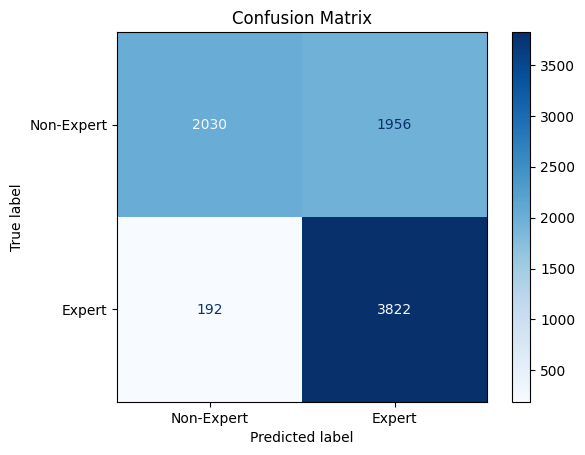

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# 生成混淆矩阵
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Expert', 'Expert'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [9]:
new_state = X_test[0]  # 示例：使用测试集中的一个状态
proba = model.predict_proba(new_state.reshape(1, -1))[0]
print(f"专家概率: {proba[1]:.4f}, 非专家概率: {proba[0]:.4f}")


专家概率: 0.6042, 非专家概率: 0.3958


/tmp/ipykernel_809169/4175669696.py:22: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, edgecolor='k', cmap=plt.cm.coolwarm, marker='x', label='Test')


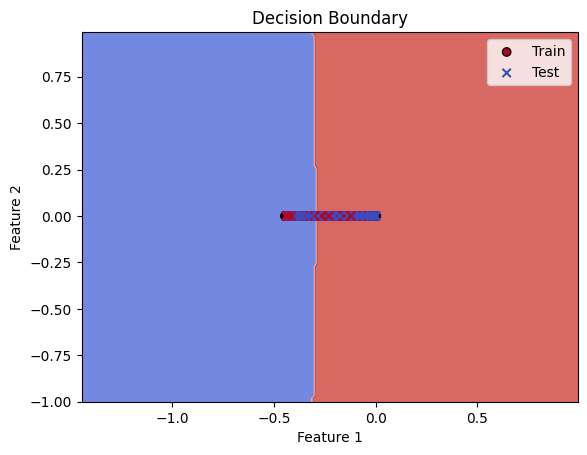

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 仅选择前两个特征以便于可视化",
X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]

# 重新训练模型以适应 2D 数据",
model_2d = make_pipeline(Nystroem(kernel='rbf', n_components=100), SGDClassifier(loss='log', max_iter=1000))
model_2d.fit(X_train_2d, y_train)

# 绘制决策边界",
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.coolwarm, marker='o', label='Train')
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, edgecolor='k', cmap=plt.cm.coolwarm, marker='x', label='Test')
plt.title('Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

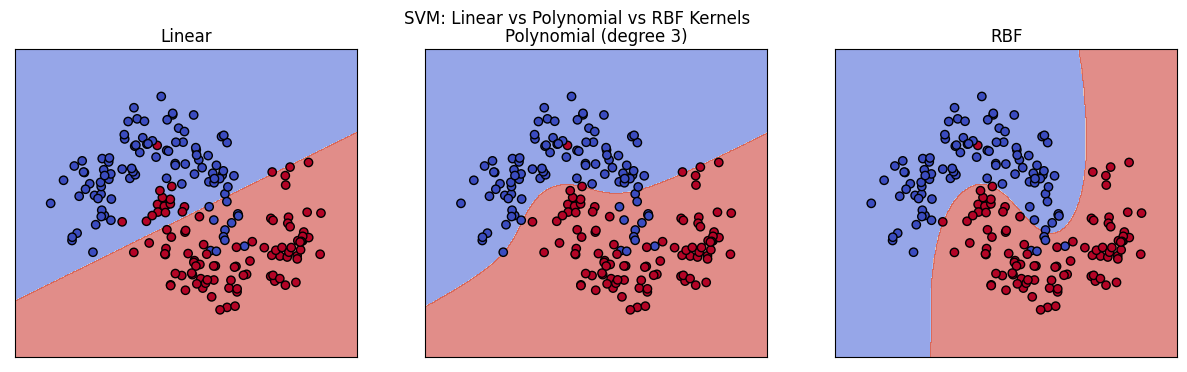

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets

# 生成模拟数据
X, y = datasets.make_moons(n_samples=200, noise=0.2, random_state=42)

# 创建三种 SVM 分类器
models = [
    ("Linear", svm.SVC(kernel="linear", C=1)),
    ("Polynomial (degree 3)", svm.SVC(kernel="poly", degree=3, C=1)),
    ("RBF", svm.SVC(kernel="rbf", gamma='scale', C=1))
]

# 绘图函数
def plot_svm(models, X, y):
    plt.figure(figsize=(15, 4))
    for i, (title, model) in enumerate(models):
        model.fit(X, y)

        # 创建网格点
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                             np.linspace(y_min, y_max, 500))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # 画图
        plt.subplot(1, 3, i + 1)
        plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6)
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
        plt.title(title)
        plt.xticks([])
        plt.yticks([])

    plt.suptitle("SVM: Linear vs Polynomial vs RBF Kernels")
    plt.show()

plot_svm(models, X, y)
